In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
import control as ct
import numpy as np

wheel_names = {0: "FL", 1: "FR", 2:"RR", 3:"RL"}
output = {"wheel_id": [0, 1, 2, 3],
          "wheel_name": [wheel_names[0], wheel_names[1], wheel_names[2], wheel_names[3]]}

# Data Acquisition

In [2]:
%%time
data = {}
logs_path = "july_testing_logs/"

for i in range(0, 101, 5):
    # intialize the dictionary of wheel dfs:
    wheels_data = {0: pd.DataFrame(), 1: pd.DataFrame(), 2: pd.DataFrame(), 3: pd.DataFrame()}
    
    # Construct file path, only change logs_path but obey this naming convention
    file_path = logs_path + str(i).zfill(3) + "_percent_pwm.log"

    headers = ["Timestamp", "Log", "Value"]
    df = pd.read_csv(file_path, skiprows=3, sep=":", on_bad_lines="skip", names=headers)
    df = df.iloc[1:]

    # Extract timestamp from log entry, assuming a specific format
    df["Timestamp"] = df["Timestamp"].str.extract(r'\[INFO\] \[([^\]]*)\] \[test logger\]').astype('float')

    # Drop rows with missing timestamps and adjust to be relative to first entry
    df = df.dropna(subset=["Timestamp"])
    df["Timestamp"] = df["Timestamp"] - df["Timestamp"].iloc[0]
    df = df.reset_index(drop=True)

    # Strip all unnecessary delimiters from Log and clean Values
    df["Log"] = df["Log"].str.replace(r'!!!', '').str.strip()
    df["Value"] = df["Value"].str.replace(r'!!!', '').str.strip()
    df["Value"] = abs(pd.to_numeric(df["Value"], errors='coerce'))

    # Knowing our wheel data is batched in 3s, we generate a DF for each wheel
    for j in range(0, len(df), 3):
        if j + 2 < len(df):
            wheel_number = int(df["Value"].iloc[j])
            wheel_df = pd.DataFrame({
                'Timestamp': df["Timestamp"].iloc[j:j+3].reset_index(drop=True),
                'Speed': df["Value"].iloc[j+1],
                'Current': df["Value"].iloc[j+2]
            })

            wheels_data[wheel_number] = pd.concat([wheels_data[wheel_number], wheel_df], ignore_index=True)
    
    data[i] = wheels_data

CPU times: user 8.61 s, sys: 51.1 ms, total: 8.66 s
Wall time: 8.68 s


# Verify Data Acquisition

In [9]:
# Choose a PWM test point (increments of 5), check that the plots in the next block make sense before continuing
# This step is purely to check and validate the data acquisition before crunching numbers
TEST_PWM = 75

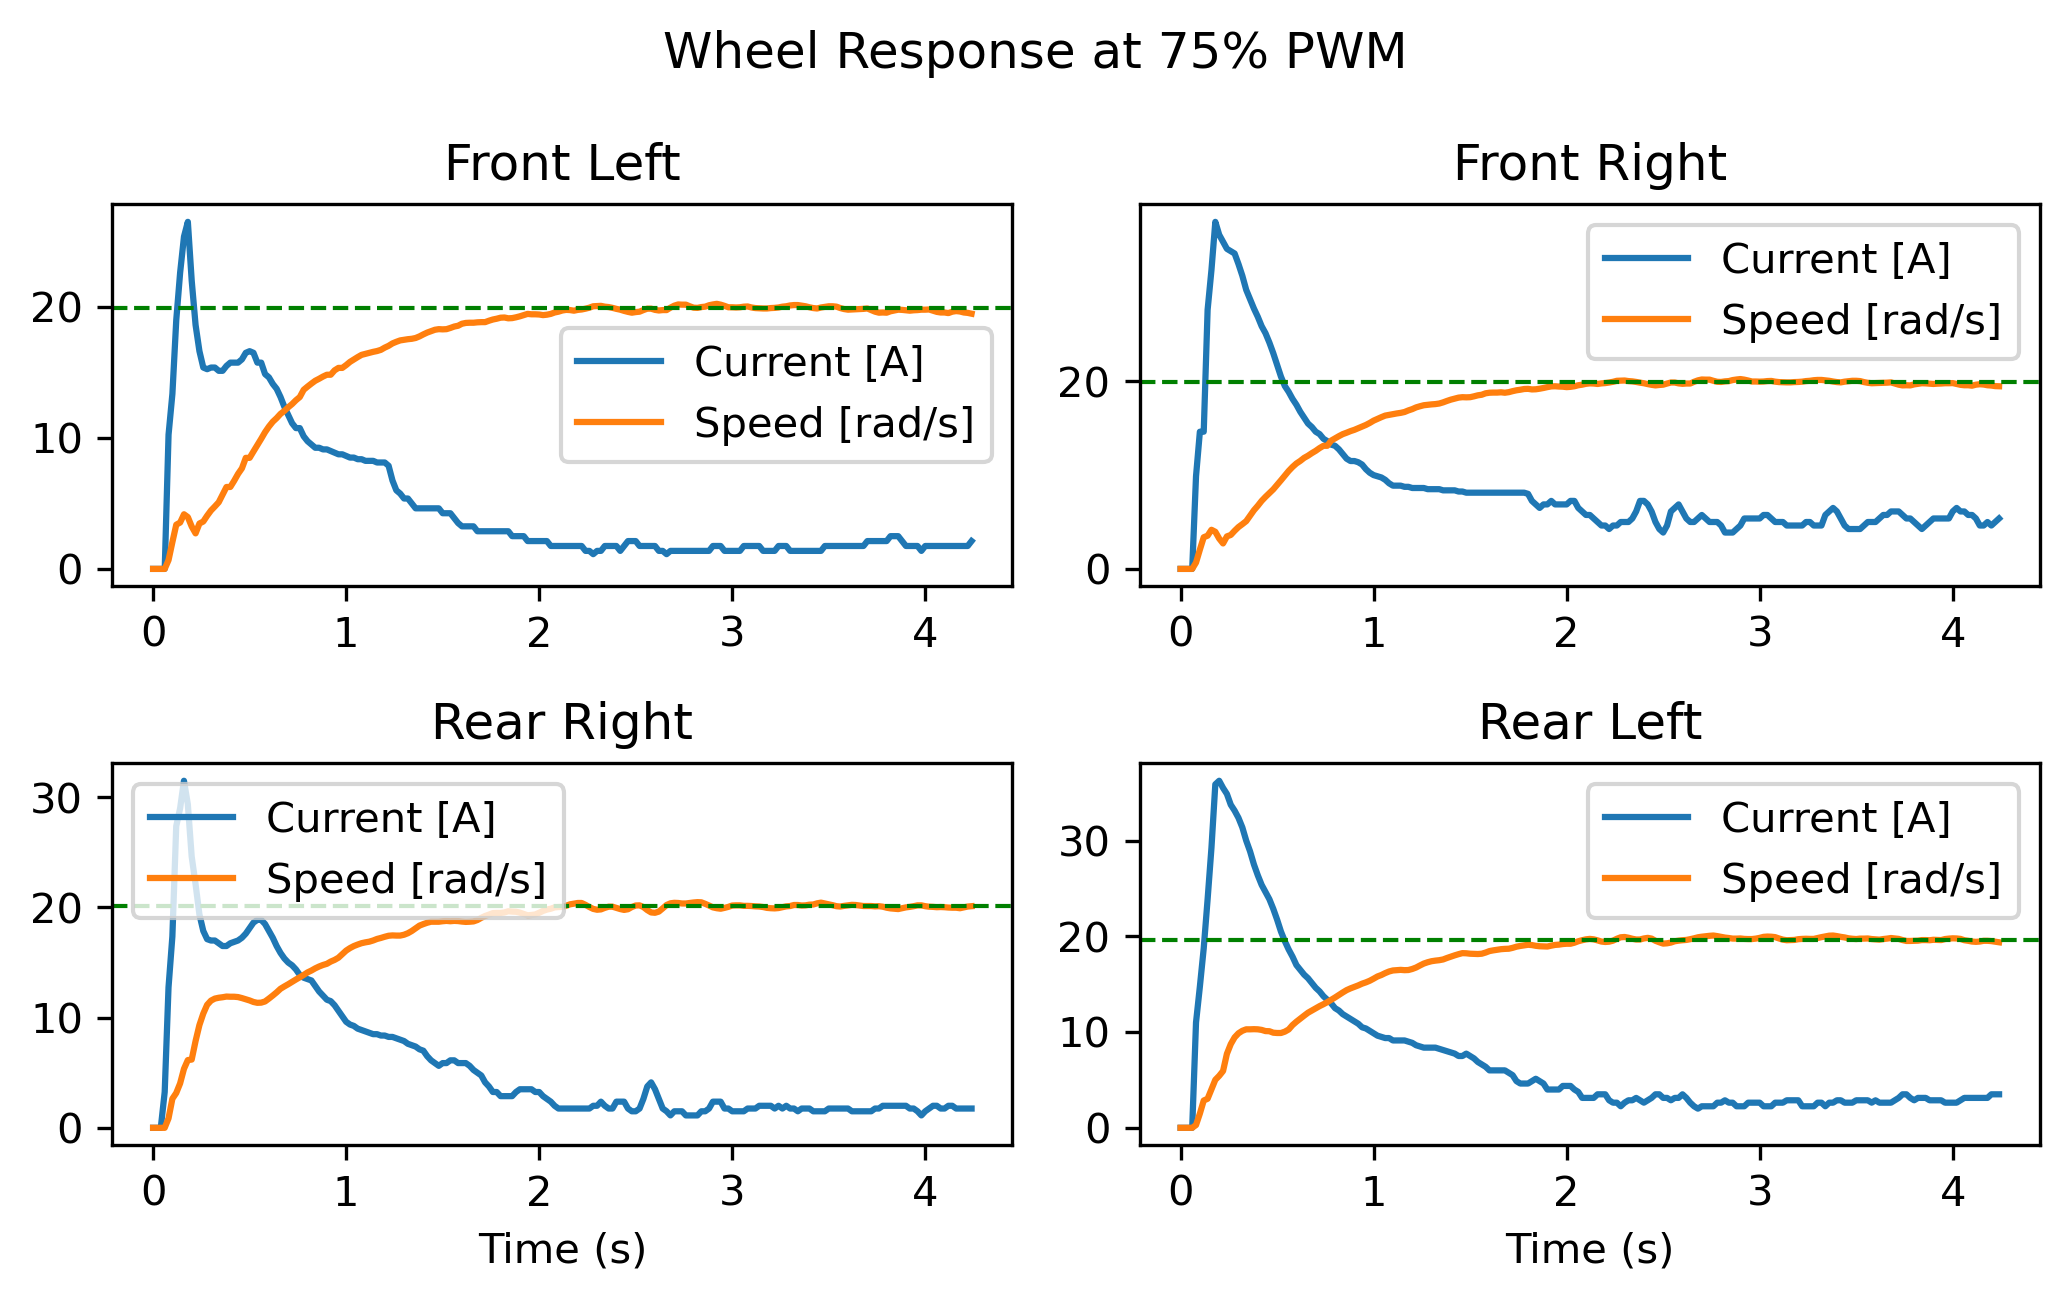

In [10]:
wheels = ["Front Left", "Front Right", "Rear Right", "Rear Left"]

fig, axs = plt.subplots(2, 2, dpi=300, figsize=[7, 7*0.625])
fig.suptitle("Wheel Response at {}% PWM".format(TEST_PWM))

for i, ax in enumerate(axs.reshape(-1)):
    df = data[TEST_PWM][i];
    df.plot(ax=ax,x='Timestamp', y="Current", label="Current [A]")
    df.plot(ax=ax,x='Timestamp', y='Speed', label="Speed [rad/s]")
    
    if i == 2 or i == 3:
        ax.set_xlabel("Time (s)")
    else:
        ax.xaxis.label.set_visible(False)
    ax.set_title("{}".format(wheels[i]))

    # Compute std deviation of the rolling average of velocity data
    df_std = df["Speed"].rolling(100).std();

    # Steady state is reached when df_std is below our threshold
    # This line grabs a series of data points that make up the window
    df_ss = df[(df_std < 0.125) | (df_std < 0.125).shift(-99)];

    # Compute the mean of the window to eliminate some measurement noise
    df_ss_mean = df_ss["Speed"].mean()

    # ... and add it to our plot
    ax.axhline(y=df_ss["Speed"].mean(), color='g', lw='1', linestyle='--')

plt.tight_layout()

# Steady State Analysis

In [5]:
# tinker with rolling window and threshold here:
# lower window and higher noise_threshold reduce precision, but eliminates NaNs
window = 23
noise_threshold = 1/8

d = {'PWM':[], 0:[], 1:[], 2:[], 3:[]}
for pwm_value in data:
    d['PWM'].append(pwm_value)
    wheels_data = data[pwm_value]
    for wheel in wheels_data:
        wheel_data = wheels_data[wheel]

        # Same rolling average process that we did in the last step
        std = wheel_data["Speed"].rolling(window).std()
        ss = wheel_data[(std < noise_threshold) | (std < noise_threshold).shift(-1*(window-1))]
        d[wheel].append(ss["Speed"].mean())

ss = pd.DataFrame(data=d)

# inspect data for NaNs, reduce precision till there are none
ss

,PWM,0,1,2,3
0,0,0.000000,0.000000,0.000000,0.000000
1,5,0.207144,0.207144,0.206867,0.199547
2,10,1.159251,1.159251,1.219432,1.155618
3,15,2.457882,2.457882,2.547629,2.421220
4,20,3.482250,3.482250,3.605446,3.429244
5,25,4.651034,4.651034,4.823152,4.617879
6,30,6.666505,6.666505,6.715832,6.566850
7,35,7.747261,7.747261,7.780691,7.664046
8,40,9.628291,9.628291,10.019923,9.596244
9,45,10.261328,10.261328,10.623613,10.109890


## Linear Regression (PWM v. Velocity)

In [6]:
pwm_velocity_model = {}
slopes = []
intercepts = []

for wheel in wheel_names:
    x = ss[["PWM"]]
    y = ss[wheel]
    model = LinearRegression()
    model.fit(x, y)
    r2_score = model.score(x,y)
    print("{} Wheel: R-squared: {}, [Slope, Y-Intercept]: [{}, {}]".format(wheel_names[wheel], r2_score, model.coef_[0], model.intercept_))
    pwm_velocity_model[wheel] = model
    slopes.append(model.coef_[0])
    intercepts.append(model.intercept_)

def pwm_to_velocity(pwm, wheel):
    model = pwm_velocity_model[wheel]
    return pwm*model.coef_[0] + model.intercept_
    
def velocity_to_pwm(velocity, wheel):
    model = pwm_velocity_model[wheel]
    return (velocity - model.intercept_)/model.coef_[0]

output["slope"] = slopes
output["intercept"] = intercepts
pwm_to_velocity(35, 3), velocity_to_pwm(5, 3)

FL Wheel: R-squared: 0.9900222174234573, [Slope, Y-Intercept]: [0.2603092442791751, -1.0323785827276346]
FR Wheel: R-squared: 0.990245341621418, [Slope, Y-Intercept]: [0.26046674828408084, -1.0373246965508631]
RR Wheel: R-squared: 0.9902017729157302, [Slope, Y-Intercept]: [0.26711748620773407, -1.1221208381746255]
RL Wheel: R-squared: 0.9954388087719401, [Slope, Y-Intercept]: [0.2667471348457357, -1.2830980308303879]


(8.053051688770362, 23.554509908659405)

# Transient Response Analysis

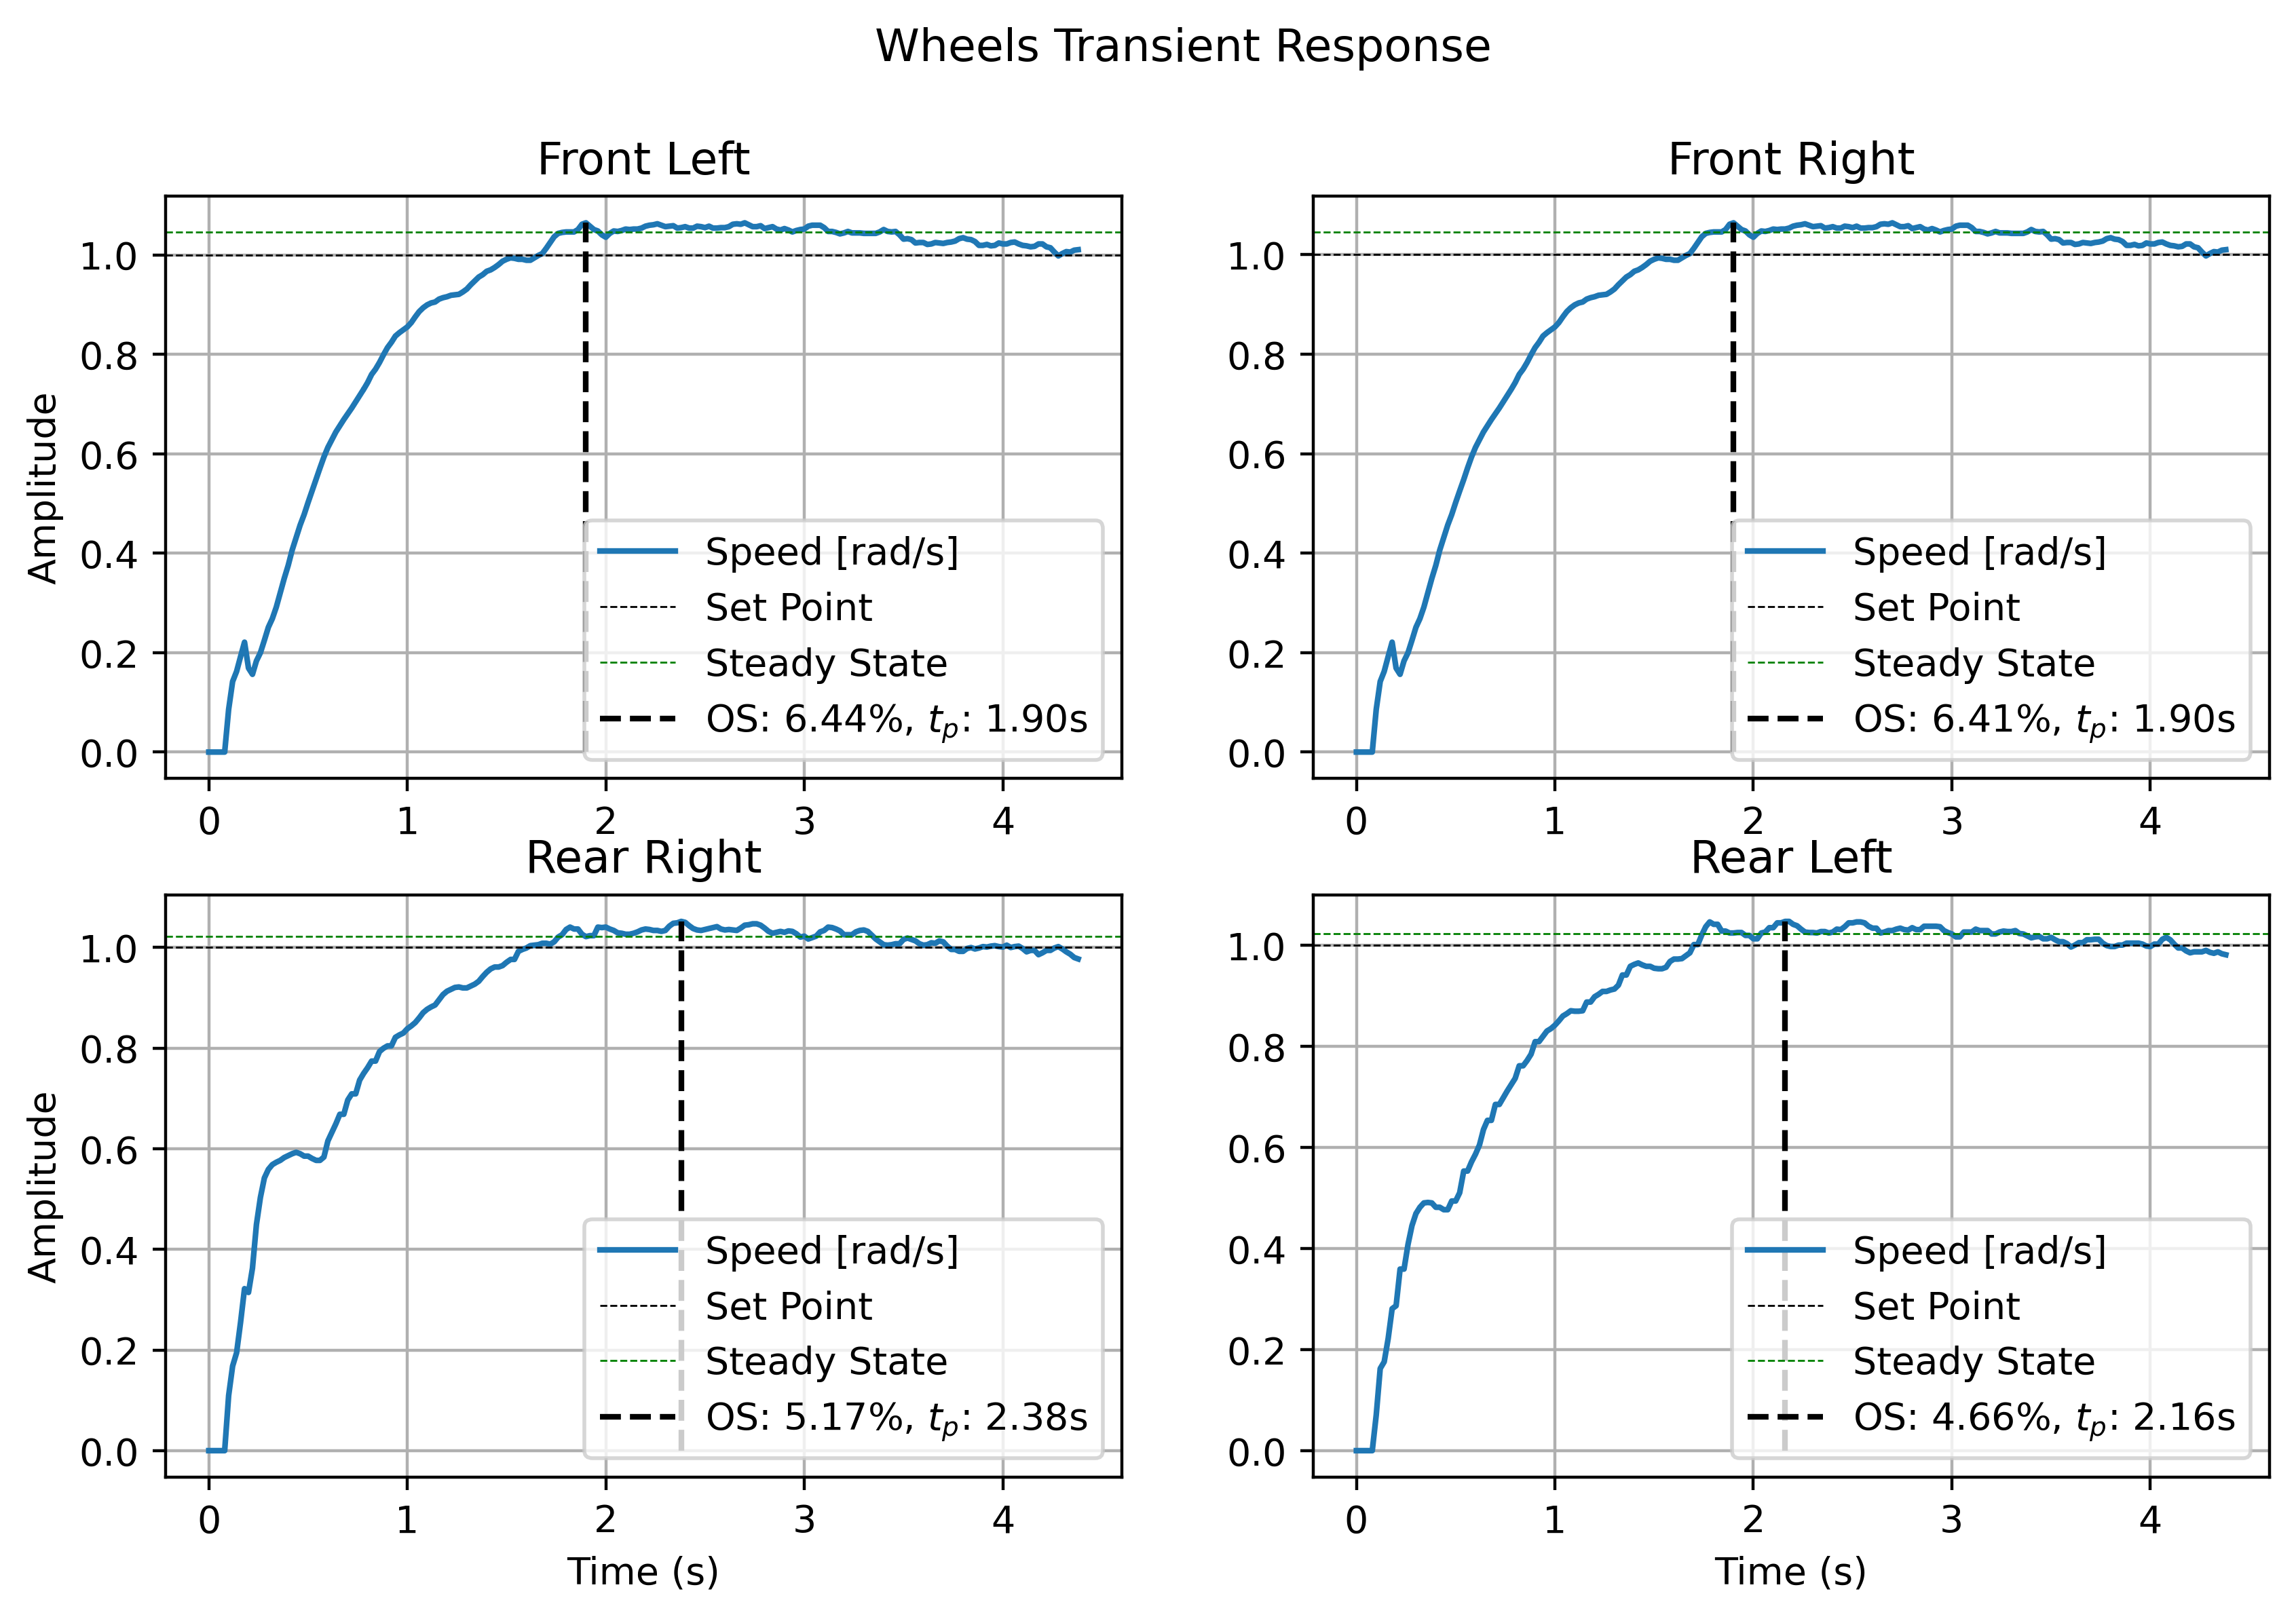

In [7]:
wheels = ["Front Left", "Front Right", "Rear Right", "Rear Left"]
tf_num = []
tf_den = []

fig, axs = plt.subplots(2, 2, dpi=400, figsize=[10, 10*0.625])
fig.suptitle("Wheels Transient Response")

for i, ax in enumerate(axs.reshape(-1)):
    df = data[65][i];
    set_point = pwm_to_velocity(65, i)

    # plot transient response, normalized to an Amplitude of 1
    ax.plot(df['Timestamp'].to_numpy(), df['Speed'].to_numpy()/set_point, label="Speed [rad/s]")

    # evaluate steady state again
    df_std = df["Speed"].rolling(100).std();
    df_ss = df[(df_std < 0.125) | (df_std < 0.125).shift(-99)];
    df_ss_mean = df_ss["Speed"].mean()

    # compute max overshoot and peak time from the maximum speed
    peak_speed = df["Speed"].max()
    overshoot_percent = peak_speed/set_point
    peak_time_idx = df["Speed"].idxmax()
    peak_time = df["Timestamp"][peak_time_idx]

    # system identification:
    omega_d = np.pi/peak_time
    sigma = -1*omega_d*np.log(overshoot_percent-1)/np.pi
    omega_n = np.sqrt(omega_d**2 + sigma**2)
    zeta = sigma/omega_n

    # build transfer function
    s = ct.tf('s')
    tf_num.append([omega_n**2])
    tf_den.append([1, 2*zeta*omega_n, omega_n**2])
        
    # ... add unity amplitude, steady state, and sys id to the plot
    ax.axhline(y=set_point/set_point, color='black', lw='0.5', linestyle='--', label='Set Point')
    ax.axhline(y=df_ss["Speed"].mean()/set_point, color='g', lw='0.5', linestyle='--', label='Steady State')
    ax.vlines(x=peak_time, ymin=0.0, ymax=overshoot_percent, colors='black', linestyles='--', label='OS: {:.2f}%, $t_p$: {:.2f}s'.format(100*(overshoot_percent-1), peak_time))

    ax.grid()
    if i == 0 or i == 2:
        ax.set_ylabel("Amplitude")
    if i == 2 or i == 3:
        ax.set_xlabel("Time (s)")
    else:
        ax.xaxis.label.set_visible(False)
    ax.set_title("{}".format(wheels[i]))
    ax.legend()

output["tf_num"] = tf_num
output["tf_den"] = tf_den

# Export to MATLAB (via .csv)

In [8]:
# make sure this matches what is in the MATLAB script
output_path = "wheel_data.csv"
output_df = pd.DataFrame(output)
output_df.to_csv(output_path, index=False)